# Boosting (EDA-9)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import joblib

## Import data

In [2]:
# Reading data
X_train = pd.read_csv('../../data/processed/X_train_eda9.csv')
X_test = pd.read_csv('../../data/processed/X_test_eda9.csv')
y_train = pd.read_csv('../../data/processed/y_train_eda9.csv')
y_test = pd.read_csv('../../data/processed/y_test_eda9.csv')

## Standard Scaler

In [3]:
# Standard Scaling for all features (X)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

## Creating model and training data - XGBoost

In [4]:
# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, 
                          subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train_scaled, y_train.values.ravel())

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Predictions

In [5]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [6]:
# Evaluate accuracy and other metrics
model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred)
model_recall = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)
model_roc_auc = roc_auc_score(y_test, y_proba)
model_cm = confusion_matrix(y_test, y_pred)
model_report = classification_report(y_test, y_pred)

In [7]:
# Showing results
model_accuracy, model_precision, model_recall, model_f1, model_roc_auc

(0.5088360595382106,
 0.513074226868079,
 0.5731760139993416,
 0.5414624166291583,
 0.5191873482556768)

In [8]:
# Showing classification report
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report

,precision,recall,f1-score,support
0.0,0.503327,0.442948,0.471211,56361.000000
1.0,0.513074,0.573176,0.541462,57717.000000
accuracy,0.508836,0.508836,0.508836,0.508836
macro avg,0.508200,0.508062,0.506337,114078.000000
weighted avg,0.508258,0.508836,0.506754,114078.000000


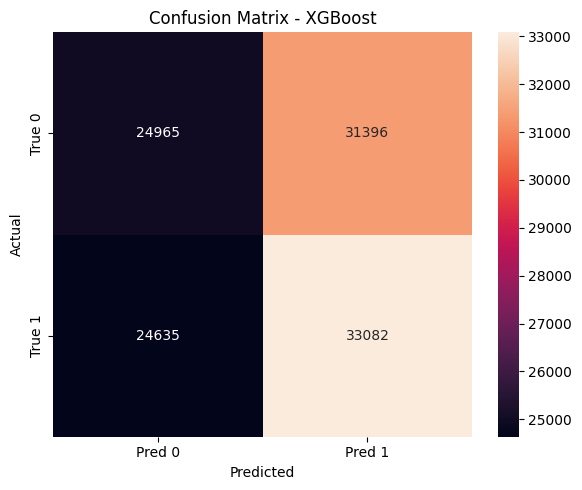

In [9]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(model_cm, annot=True, fmt='d', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])

plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

## Optimization

In [10]:
# Hyperparameters to test
hyperparams = {'n_estimators' : [100, 200],
               'learning_rate' : [0.05, 0.1],
               'max_depth' : [2, 3, 4],
               'min_split_loss' : [0, 0.1],
               'subsample' : [0.7, 0.8],
               'colsample_bytree' : [0.7, 0.8]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search = GridSearchCV(xgb_model, hyperparams, scoring='roc_auc', cv=tscv, n_jobs=-1)
grid_search.fit(X_train, y_train.values.ravel())

KeyboardInterrupt: 

In [ ]:
# Best parameters and evaluation
grid_model_xgb = grid_search.best_estimator_

y_pred_opt = grid_model_xgb.predict(X_test)
y_proba_opt = grid_model_xgb.predict_proba(X_test)[:,1]

In [ ]:
# Metrics for optimized model
test_accuracy = accuracy_score(y_test, y_pred_opt)
test_precision = precision_score(y_test, y_pred_opt)
test_recall = recall_score(y_test, y_pred_opt)
test_f1 = f1_score(y_test, y_pred_opt)
test_roc_auc = roc_auc_score(y_test, y_proba_opt)

In [ ]:
# Showing results
test_accuracy, test_precision, test_recall, test_f1, test_roc_auc

(0.5092480583460439,
 0.5132937512465289,
 0.5796732331895282,
 0.5444677700206676,
 0.5181919930123612)

In [ ]:
# Showing classification report
report_dict2 = classification_report(y_test, y_pred_opt, output_dict=True)
df_report2 = pd.DataFrame(report_dict2).transpose()
df_report2

,precision,recall,f1-score,support
0.0,0.503855,0.437129,0.468126,56361.000000
1.0,0.513294,0.579673,0.544468,57717.000000
accuracy,0.509248,0.509248,0.509248,0.509248
macro avg,0.508574,0.508401,0.506297,114078.000000
weighted avg,0.508630,0.509248,0.506751,114078.000000


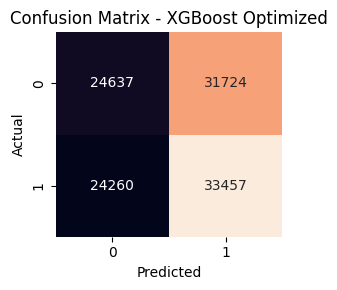

In [ ]:
# Plotting confussion matrix
cm = confusion_matrix(y_test, y_pred_opt)
df_cm = pd.DataFrame(cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt='d', cbar=False)
plt.title('Confusion Matrix - XGBoost Optimized')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Creating model and training data - Gradient Boosting

In [ ]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42)

# Train the model
gb_model.fit(X_train, y_train.values.ravel())

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Predictions

In [ ]:
# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate accuracy and other metrics
model_accuracy_gb = accuracy_score(y_test, y_pred_gb)
model_precision_gb = precision_score(y_test, y_pred_gb)
model_recall_gb = recall_score(y_test, y_pred_gb)
model_f1_gb = f1_score(y_test, y_pred_gb)
model_roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)

In [ ]:
# Showing results
model_accuracy_gb, model_precision_gb, model_recall_gb, model_f1_gb, model_roc_auc_gb

(0.5095285681726538,
 0.5138333725213575,
 0.5679435868115114,
 0.5395351899400882,
 0.5205054500177647)

In [ ]:
# Showing classification report
report_dict3 = classification_report(y_test, y_pred_gb, output_dict=True)
df_report3 = pd.DataFrame(report_dict3).transpose()
df_report3

,precision,recall,f1-score,support
0.0,0.504067,0.449708,0.475339,56361.000000
1.0,0.513833,0.567944,0.539535,57717.000000
accuracy,0.509529,0.509529,0.509529,0.509529
macro avg,0.508950,0.508826,0.507437,114078.000000
weighted avg,0.509008,0.509529,0.507818,114078.000000


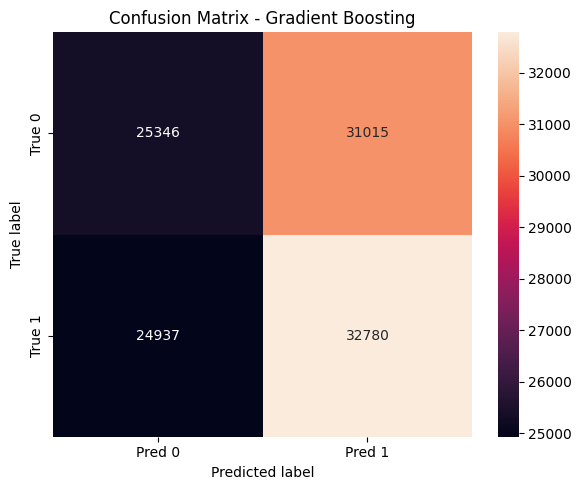

In [ ]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])

plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('True label')
plt.xlabel('Predicted label')

plt.tight_layout()
plt.show()

In [ ]:
# Classification report
classification_report(y_test, y_pred_gb, digits=3)

'              precision    recall  f1-score   support\n\n         0.0      0.504     0.450     0.475     56361\n         1.0      0.514     0.568     0.540     57717\n\n    accuracy                          0.510    114078\n   macro avg      0.509     0.509     0.507    114078\nweighted avg      0.509     0.510     0.508    114078\n'

## Optimization

In [ ]:
# Hyperparameters to test
hyperparams_gb = {'n_estimators' : [100, 200],
                  'learning_rate' : [0.05, 0.1],
                  'max_depth' : [2, 3, 4],
                  'subsample' : [0.7, 0.8],
                  'max_features' : ['sqrt', 'log2']}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search_gb = GridSearchCV(gb_model, hyperparams_gb, scoring='roc_auc', cv=tscv, n_jobs=-1)
grid_search_gb.fit(X_train, y_train.values.ravel())

,estimator,GradientBoost...subsample=0.8)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [ ]:
# Best parameters and evaluation
grid_model_gb = grid_search_gb.best_estimator_

y_pred_gb_opt = grid_model_gb.predict(X_test)
y_proba_gb_opt = grid_model_gb.predict_proba(X_test)[:,1]

In [ ]:
# Metrics for optimized model
test_accuracy_gb = accuracy_score(y_test, y_pred_gb_opt)
test_precision_gb = precision_score(y_test, y_pred_gb_opt)
test_recall_gb = recall_score(y_test, y_pred_gb_opt)
test_f1_gb = f1_score(y_test, y_pred_gb_opt)
test_roc_auc_gb = roc_auc_score(y_test, y_proba_gb_opt)

In [ ]:
# Showing results
test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb, test_roc_auc_gb

(0.5107032030715826,
 0.5145301238006336,
 0.5825493355510508,
 0.5464311252681532,
 0.5195137242070174)

In [ ]:
# Showing classification report
report_dict4 = classification_report(y_test, y_pred_gb_opt, output_dict=True)
df_report4 = pd.DataFrame(report_dict4).transpose()
df_report4

,precision,recall,f1-score,support
0.0,0.505571,0.437129,0.468865,56361.000000
1.0,0.514530,0.582549,0.546431,57717.000000
accuracy,0.510703,0.510703,0.510703,0.510703
macro avg,0.510051,0.509839,0.507648,114078.000000
weighted avg,0.510104,0.510703,0.508109,114078.000000


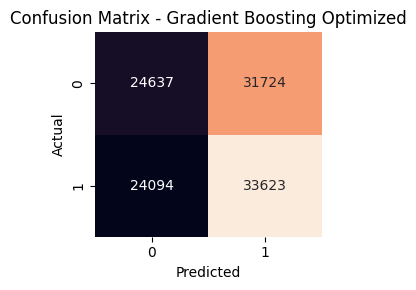

In [ ]:
# Plotting confussion matrix
bank_cm4 = confusion_matrix(y_test, y_pred_gb_opt)
df_cm4 = pd.DataFrame(bank_cm4)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm4, annot=True, fmt='d', cbar=False)
plt.title('Confusion Matrix - Gradient Boosting Optimized')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Save model and scaler

In [ ]:
# Saving best model
joblib.dump(grid_model_gb, '../../models/gradient-model-final.pkl')

['../../models/gradient-model-final.pkl']

In [ ]:
# Saving scaler
joblib.dump(scaler, '../../models/scaler-model-final.pkl')

['../../models/scaler-model-final.pkl']